## Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,accuracy_score

import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [ ]:
columns = ['age','workclass','fnlwgt','education','education-num','marital-status','occupation','relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country','income']
df = pd.read_csv('data\adult.data',sep=",",names=columns,skipinitialspace=True)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df_test = pd.read_csv("data\adult.test",names=columns,skipinitialspace=True)
df_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
16277,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K.
16278,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
16279,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


## Data Understanding

In [4]:
df.shape

(32561, 15)

In [5]:
df_test.shape

(16281, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
for i in df.columns :
    print(i,df[i].unique())
    print("Number of unique values :",df[i].nunique())
    print("  "*20)

age [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
Number of unique values : 73
                                        
workclass ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
Number of unique values : 9
                                        
fnlwgt [ 77516  83311 215646 ...  34066  84661 257302]
Number of unique values : 21648
                                        
education ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
Number of unique values : 16
                                        
education-num [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
Number of unique values : 16
                                 

## Data Cleaning

### Train

In [8]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(24)

In [10]:
df.drop_duplicates(inplace=True)

### Test

In [11]:
df_test.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

## Data Preprocessing

In [13]:
df['workclass'] = df['workclass'].replace('?', np.nan)

df_test['workclass'] = df_test['workclass'].replace('?', np.nan)

In [14]:
df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)

df_test['workclass'].fillna(df_test['workclass'].mode()[0], inplace=True)

In [15]:
df = pd.get_dummies(df, columns=['workclass'], drop_first=True)

df_test = pd.get_dummies(df_test, columns=['workclass'], drop_first=True)

In [16]:
df.drop(columns=["education"],inplace=True)

df_test.drop(columns=["education"],inplace=True)

In [17]:
df = pd.get_dummies(df,columns=['marital-status'],drop_first=True)

df_test = pd.get_dummies(df_test,columns=['marital-status'],drop_first=True)

In [18]:
df['occupation'].value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
?                    1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [19]:
df['occupation'] = df['occupation'].replace('?', np.nan)

df_test['occupation'] = df_test['occupation'].replace('?', np.nan)

In [20]:
df['occupation'].fillna(df['occupation'].mode()[0],inplace=True)

df_test['occupation'].fillna(df_test['occupation'].mode()[0],inplace=True)

In [21]:
df = pd.get_dummies(df,columns=['occupation'],drop_first=True)

df_test = pd.get_dummies(df_test,columns=['occupation'],drop_first=True)

In [22]:
df = pd.get_dummies(df, columns=['relationship'], drop_first=True)

df_test = pd.get_dummies(df_test, columns=['relationship'], drop_first=True)

In [23]:
df = pd.get_dummies(df, columns=['race'], drop_first=True)

df_test = pd.get_dummies(df_test, columns=['race'], drop_first=True)

In [24]:
df['sex'] = df['sex'].map({'Female': 0,'Male': 1})

df_test['sex'] = df_test['sex'].map({'Female': 0,'Male': 1})

In [25]:
df['native-country'].value_counts()

native-country
United-States                 29153
Mexico                          639
?                               582
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        62
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [26]:
df['native-country'] = df['native-country'].replace('?', np.nan)

df_test['native-country'] = df_test['native-country'].replace('?', np.nan)

In [27]:
df['native-country'] = df['native-country'].apply(lambda x: 'US' if x == 'United-States' else 'Non-US')

df_test['native-country'] = df_test['native-country'].apply(lambda x: 'US' if x == 'United-States' else 'Non-US')

In [28]:
df = pd.get_dummies(df,columns=['native-country'],drop_first=True)

df_test = pd.get_dummies(df_test,columns=['native-country'],drop_first=True)

### Target Column

In [29]:
df['income'] = df['income'].map({'<=50K': 0,'>50K': 1})

df_test['income'] = df_test['income'].str.rstrip('.').map({'<=50K': 0, '>50K': 1})

In [30]:
df.select_dtypes(include=object)

""
0
1
2
3
4
...
32556
32557
32558
32559


## Exploratory Data Analysis



### Income Distribution

Text(0.5, 1.0, 'Income Distribution')

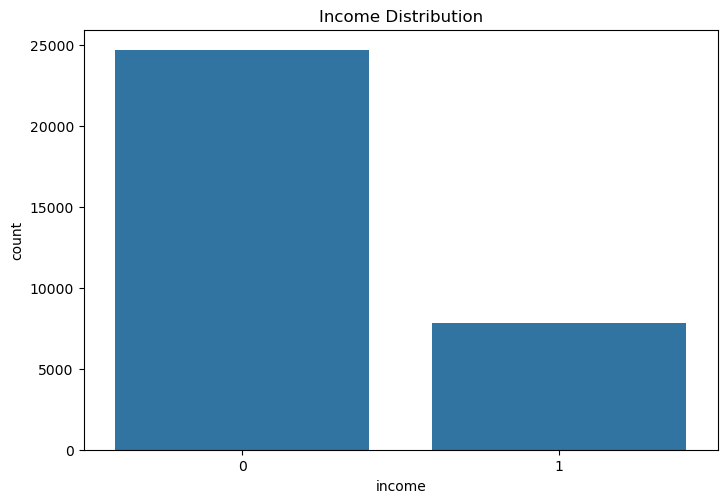

In [31]:
plt.figure(figsize=(18, 12))
plt.subplot(2, 2, 1)
sns.countplot(x='income', data=df)
plt.title('Income Distribution')

### Age vs Income

Text(0.5, 1.0, 'Age vs Income')

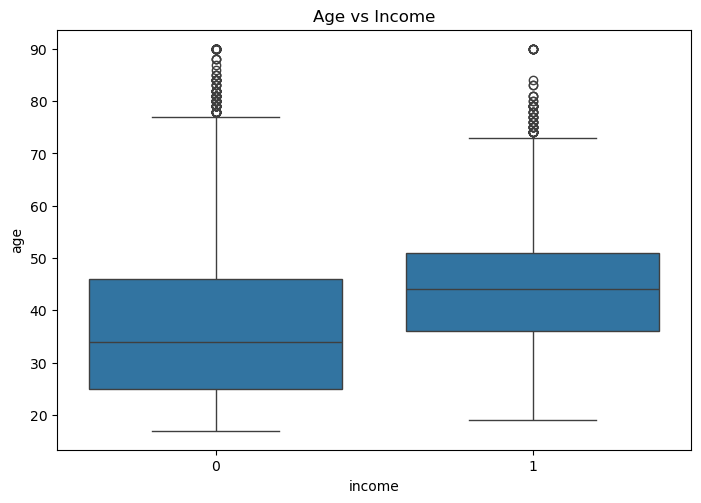

In [32]:
plt.figure(figsize=(18, 12))
plt.subplot(2, 2, 2)
sns.boxplot(x='income', y='age', data=df)
plt.title('Age vs Income')

### Education Analysis

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12'),
  Text(12, 0, '13'),
  Text(13, 0, '14'),
  Text(14, 0, '15'),
  Text(15, 0, '16')])

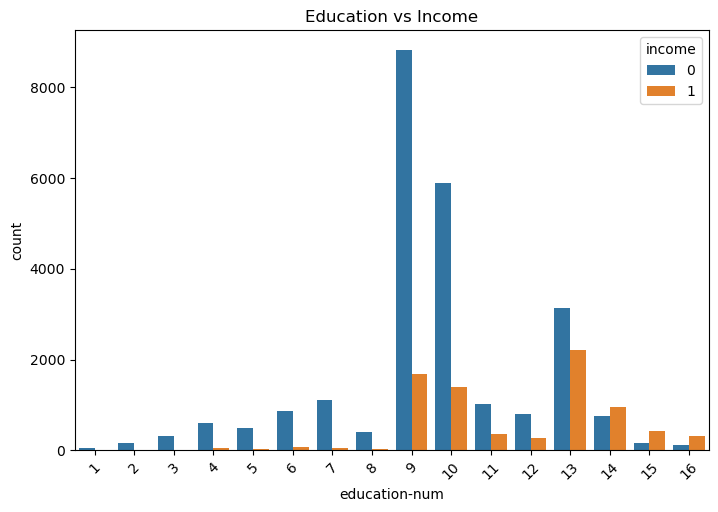

In [33]:
plt.figure(figsize=(18, 12))
plt.subplot(2, 2, 3)
sns.countplot(x='education-num',hue='income',data=df)
plt.title('Education vs Income')
plt.xticks(rotation=45)


## Feature Selection

In [34]:
# Train 
X_train = df.drop("income", axis=1)
y_train = df["income"]

# Test
X_test = df_test.drop("income", axis=1)
y_test = df_test["income"]

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 44 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   age                                   32537 non-null  int64
 1   fnlwgt                                32537 non-null  int64
 2   education-num                         32537 non-null  int64
 3   sex                                   32537 non-null  int64
 4   capital-gain                          32537 non-null  int64
 5   capital-loss                          32537 non-null  int64
 6   hours-per-week                        32537 non-null  int64
 7   income                                32537 non-null  int64
 8   workclass_Local-gov                   32537 non-null  bool 
 9   workclass_Never-worked                32537 non-null  bool 
 10  workclass_Private                     32537 non-null  bool 
 11  workclass_Self-emp-inc                32537 no

In [36]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Building

### 1. SVM (Linear Kernel)


In [37]:
linear_svm = SVC(kernel='linear', random_state=42)

linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

In [38]:
print("Linear SVM Accuracy:",accuracy_score(y_test, y_pred_linear))

Linear SVM Accuracy: 0.8524046434494196


### 2. SVM (RBF Kernel)


In [39]:
rbf_svm = SVC(kernel='rbf', random_state=42)

rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)

In [40]:
print("RBF SVM Accuracy:",accuracy_score(y_test, y_pred_rbf))

RBF SVM Accuracy: 0.8552914440144954


## Hyperparameter Tuning

In [41]:
params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(),params,scoring='accuracy',verbose=1)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
0.853951009593092


## Final Tuned Model

In [42]:
model = SVC(kernel='rbf',C=10,gamma=0.01,random_state=42)

model.fit(X_train,y_train)

predict = model.predict(X_test)

In [43]:
print("Accuracy:",accuracy_score(y_test, predict))

print(classification_report(y_test, predict))

Accuracy: 0.8536330692217923
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     12435
           1       0.74      0.59      0.66      3846

    accuracy                           0.85     16281
   macro avg       0.81      0.76      0.78     16281
weighted avg       0.85      0.85      0.85     16281



In [44]:
model.score(X_train,y_train),model.score(X_test,y_test)

(0.8659065064388235, 0.8536330692217923)

## Conclusion


The Adult Income dataset was preprocessed using missing value handling, categorical encoding, and feature scaling. Two SVM models (Linear and RBF Kernel) were trained and evaluated. The tuned RBF Kernel SVM achieved the best performance, demonstrating that non-linear decision boundaries improved income classification accuracy. This project highlights the effectiveness of SVM for binary classification tasks involving demographic and employment-related features.